## Contexto do caso

Um **telex** era um terminal que enviava e recebia mensagens curtas por uma rede de telecomunicações, décadas antes da internet. No contexto do caso, ele representa o meio pelo qual a central recebe informações operacionais das unidades.

Cada **remessa** é uma carga individual que precisa sair de uma origem e chegar a um destino. O contexto histórico inspira o cenário, mas os lugares, registros e resultados desta prova são inteiramente sintéticos.


# Gabarito docente - A1 prática: Operação de abastecimento CyberSyn

Solução de referência publicada pelo professor para consulta após a prova.


## Como consultar o gabarito

- As soluções estão organizadas por questão; cada célula carrega os arquivos necessários.
- Os códigos e resultados já executados aparecem no caderno. Você também pode clicar em **Executar** para reproduzi-los no navegador.
- As respostas em texto são exemplos de interpretação, não a única redação aceitável.
- Use **Baixar gabarito .ipynb** para guardar uma cópia com as soluções e saídas.


## Arquivos disponíveis

- `dados/carregamentos_brutos.csv`: fila de remessas com problemas intencionais.
- `dados/carregamentos_analise.csv`: base sintética pronta para as Questões 3 e 4.
- `dados/dicionario-cybersyn-abastecimento.md`: contexto, campos e limites.

Consulte o **Dicionário de dados** no menu superior antes de começar.


---
## Questão 1 — Leitura da fila de remessas (0,5 ponto)

Em uma célula de código, carregue `dados/carregamentos_brutos.csv` e mostre:

1. as cinco primeiras linhas;
2. a quantidade de linhas e colunas da tabela;
3. os tipos de dados das colunas; e
4. a quantidade de valores ausentes, mostrando somente as colunas que têm ao menos uma ausência. Exiba essa última informação como uma série ou tabela sem colunas com zero ausência.

No campo de resposta, registre uma limitação que impeça generalizar os resultados para a greve real de 1972 ou para a logística de todo o Chile.


In [1]:
# Uso pandas porque a inspeção envolve uma tabela CSV e operações por coluna.
import pandas as pd

# Leio a base bruta para identificar problemas antes de qualquer tratamento.
dados = pd.read_csv("dados/carregamentos_brutos.csv")
# Conto os vazios por campo para localizar limitações dos dados recebidos.
ausencias = dados.isna().sum()
# Informo o número de linhas para dimensionar a fila de remessas.
print(f"Linhas: {dados.shape[0]}")
# Informo o número de colunas para verificar a estrutura disponível.
print(f"Colunas: {dados.shape[1]}")
# Separo a saída de tipos para facilitar a leitura do diagnóstico.
print("\nTipos de dados:")
# Examino os tipos porque campos numéricos lidos como texto exigirão limpeza.
print(dados.dtypes)
# Identifico a seção de ausências que pode afetar os cálculos seguintes.
print("\nAusências apenas onde existem:")
# Mostro apenas colunas com faltas para concentrar a atenção nos problemas reais.
print(ausencias[ausencias > 0])
# Pré-visualizo linhas para conferir valores e grafias que as contagens não mostram.
dados.head()


Linhas: 81
Colunas: 14

Tipos de dados:
id_carregamento                      str
data_registro                        str
tipo_carga                           str
origem                               str
destino                              str
prioridade_solicitada                str
distancia_km                         str
estoque_destino_dias                 str
caminhoes_disponiveis              int64
combustivel_disponivel_litros      int64
peso_toneladas                   float64
carga_perecivel                    int64
prazo_horas                          str
telex_origem                         str
dtype: object

Ausências apenas onde existem:
distancia_km            5
estoque_destino_dias    9
prazo_horas             8
dtype: int64


,id_carregamento,data_registro,tipo_carga,origem,destino,prioridade_solicitada,distancia_km,estoque_destino_dias,caminhoes_disponiveis,combustivel_disponivel_litros,peso_toneladas,carga_perecivel,prazo_horas,telex_origem
0,CS-0001,1972/10/14 15:30,Alimentos básicos,Armazém Ferroviário,Antofagasta,Média,"347,9","4,5",2,721,5.4,1,"24,2",T-15
1,CS-0002,1972-10-18 15:30,insumos,Depósito Norte,Talca,Média,"274,4","5,9",11,622,9.5,0,"24,4",T-04
2,CS-0003,1972/10/28 07:45,MEDICAMENTOS,Terminal Costeiro,Talca,Média,"120,8","6,0",4,1761,4.4,0,"16,1",T-15
3,CS-0004,25/10/1972 15:15,combustivel,Armazém Ferroviário,Antofagasta,Média,"295,8","4,8",1,2871,7.0,0,"23,1",T-04
4,CS-0005,1972/10/24 09:15,INSUMOS INDUSTRIAIS,Terminal Costeiro,Concepción,Média,"557,4","2,8",4,1733,4.8,0,"31,7",T-12


**Resposta da Questão 1 — limite de interpretação:**

Os registros são sintéticos e não permitem generalizar conclusões para a greve real de 1972 ou para toda a logística chilena.


---
## Questão 2 — Restauro e margem de abastecimento (1,5 ponto)

A fila chegou por telex com registros repetidos, grafias diferentes e alguns campos ausentes. Parta novamente de `dados/carregamentos_brutos.csv`, em uma nova variável, e:

1. remova duplicidades por `id_carregamento`;
2. padronize `tipo_carga`;
3. converta os campos numéricos usados no cálculo;
4. remova as linhas sem os dados necessários para calcular a margem; e
5. crie `margem_abastecimento_horas`, definida por:

$$margem\_abastecimento\_horas = estoque\_destino\_dias \times 24 - prazo\_horas$$

Depois, produza uma tabela por `tipo_carga` com o número de remessas e a mediana da margem. Uma margem menor representa menos folga entre o estoque estimado e o prazo operacional.

**Dica:** ao usar `pd.to_numeric(..., errors="coerce")`, um valor que não puder ser convertido vira ausência (`NaN`). Depois, `dropna(subset=[...])` permite remover apenas as linhas sem os dados necessários ao cálculo.


In [2]:
# Uso pandas para limpar, converter e resumir os registros tabulares.
import pandas as pd

# Releio a base bruta para que esta questão não dependa da anterior.
dados = pd.read_csv("dados/carregamentos_brutos.csv")
# Removo IDs duplicados para não contar a mesma remessa mais de uma vez.
dados = dados.drop_duplicates(subset="id_carregamento").copy()
# Uniformizo espaços e maiúsculas para agrupar categorias equivalentes.
dados["tipo_carga"] = dados["tipo_carga"].str.strip().str.lower()
# Aplico a mesma conversão aos dois campos necessários para calcular a margem.
for coluna in ["estoque_destino_dias", "prazo_horas"]:
    # Troco vírgula decimal por ponto para permitir a interpretação numérica.
    valores = dados[coluna].astype(str).str.replace(",", ".", regex=False)
    # Converto números e marco entradas inválidas como ausentes para tratá-las depois.
    dados[coluna] = pd.to_numeric(valores, errors="coerce")
# Excluo linhas sem as duas medidas indispensáveis para uma margem confiável.
dados = dados.dropna(subset=["estoque_destino_dias", "prazo_horas"]).copy()
# Converto dias em horas antes de subtrair o prazo, mantendo as unidades iguais.
dados["margem_abastecimento_horas"] = dados["estoque_destino_dias"] * 24 - dados["prazo_horas"]
# Agrupo as operações para deixar a tabela resumida como resultado da célula.
(
    # Comparo remessas do mesmo tipo de carga após padronizar suas grafias.
    dados.groupby("tipo_carga")
    # Conto remessas e uso a mediana para resumir margens sem depender de extremos.
    .agg(remessas=("id_carregamento", "size"), mediana_margem=("margem_abastecimento_horas", "median"))
    # Ordeno pelas menores margens para destacar primeiro os grupos mais pressionados.
    .sort_values("mediana_margem")
    # Arredondo apenas a apresentação para facilitar a leitura da tabela.
    .round(2)
# Concluo a expressão para exibir o resumo como saída do caderno.
)


,remessas,mediana_margem
tipo_carga,,
alimentos,3,16.00
combustível,6,28.00
alimentos básicos,4,33.25
insumos industriais,12,54.55
combustivel,12,62.10
medicamentos,9,64.10
insumos,7,73.90
alimentos basicos,6,84.60
medicamento,3,125.00


**Resposta da Questão 2 — decisões de limpeza:**

Duplicidades foram removidas, o tipo de carga foi padronizado e as colunas necessárias foram convertidas. Linhas sem estoque ou prazo foram removidas com `dropna`.


---
## Questão 3 — Painel de pressão no abastecimento (1,5 ponto)

Use **somente** `dados/carregamentos_analise.csv`. Crie `margem_abastecimento_horas` com a mesma fórmula da Questão 2. A sala de operações precisa observar onde há menos folga antes de decidir a distribuição dos caminhões.

Crie uma tabela com o número de remessas e a mediana da margem por `destino`. Ordene-a da **menor para a maior margem** e faça um gráfico de barras na mesma ordem para comparar os destinos. O gráfico deve ter título informativo e eixos nomeados.

No campo de resposta, escreva uma recomendação de 2 a 3 frases: indique um destino que merece atenção, explique brevemente o que a mediana mostra e registre uma limitação da análise.

**Dica:** a mediana representa uma remessa típica do grupo; ela ajuda a comparar destinos, mas não demonstra a causa da pressão observada.


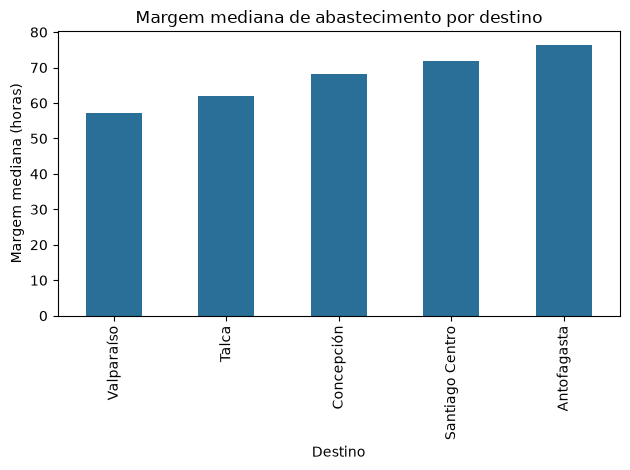

,destino,n_remessas,mediana_margem
4,Valparaíso,32,57.3
3,Talca,37,61.9
1,Concepción,45,68.3
2,Santiago Centro,46,71.9
0,Antofagasta,40,76.4


In [3]:
# Carrego a biblioteca de gráficos para comunicar as diferenças entre destinos.
import matplotlib.pyplot as plt
# Uso pandas para ler a base de análise e calcular o resumo.
import pandas as pd

# Leio a base já tratada, adequada a esta comparação entre destinos.
dados = pd.read_csv("dados/carregamentos_analise.csv")
# Ponho estoque e prazo em horas para medir a folga antes do limite.
dados["margem_abastecimento_horas"] = dados["estoque_destino_dias"] * 24 - dados["prazo_horas"]
# Inicio uma tabela de resumo para sustentar o gráfico e a recomendação.
resumo_destino = (
    # Agrupo por destino mantendo o nome como coluna para usá-lo no eixo horizontal.
    dados.groupby("destino", as_index=False)
    # Conto remessas e calculo a margem mediana para combinar volume e folga típica.
    .agg(n_remessas=("id_carregamento", "size"), mediana_margem=("margem_abastecimento_horas", "median"))
    # Ordeno a menor margem primeiro para revelar os destinos sob maior pressão.
    .sort_values("mediana_margem")
# Concluo o resumo que será apresentado em tabela e no gráfico.
)
# Uso barras para comparar os destinos em uma escala comum.
ax = resumo_destino.plot.bar(x="destino", y="mediana_margem", legend=False, color="#2a6f97")
# Nomeio título e eixos para deixar clara a medida e sua unidade.
ax.set(title="Margem mediana de abastecimento por destino", xlabel="Destino", ylabel="Margem mediana (horas)")
# Ajusto o espaço do gráfico para não cortar rótulos.
plt.tight_layout()
# Exibo o gráfico no resultado da célula.
plt.show()
# Mostro os valores arredondados para conferir visualmente a comparação.
resumo_destino.round(2)


**Resposta da Questão 3 — recomendação operacional:**

O destino com menor margem merece atenção porque tem menos folga antes do prazo. A mediana descreve uma remessa típica; como os dados são sintéticos, ela não permite identificar a causa dessa pressão.


---
## Questão 4 — Prioridade de despacho (2,5 pontos)

A central precisa decidir, antes de o caminhão sair, quais remessas merecem acompanhamento extraordinário. A decisão é binária: “prioridade de despacho” ou “prioridade normal”.

### 4.1 — Tipo de problema

Indique no campo de resposta o tipo de aprendizado de máquina adequado — regressão, classificação ou clusterização — e justifique brevemente a escolha.

### 4.2 — Variável-alvo

Crie `atrasou_entrega`: valor 1 quando `tempo_entrega_horas` for maior que `prazo_horas`; valor 0 nos demais casos.

`tempo_entrega_horas` só é conhecido depois da entrega. Por isso, ele serve para criar o alvo que o modelo tentará prever, e não para compor as variáveis de entrada.

### 4.3 — Variáveis de entrada

Antes de preparar as variáveis de entrada, crie `margem_abastecimento_horas = estoque_destino_dias × 24 − prazo_horas`. Use somente estas informações conhecidas no registro: `tipo_carga`, `destino`, `prioridade_solicitada`, `distancia_km`, `estoque_destino_dias`, `carga_perecivel`, `prazo_horas` e `margem_abastecimento_horas`. Não use `tempo_entrega_horas` nem variáveis posteriores à saída.

Essas variáveis de entrada são as **features**: informações que a central já possui antes de o caminhão sair. Usar um resultado posterior à saída seria **vazamento de informação** e daria ao modelo uma pista que ele não teria no momento da decisão.

### 4.4 — Modelo e avaliação

Separe 75% das remessas para treino e 25% para teste, usando `random_state=42` e preservando a proporção de atrasos nos dois conjuntos. Prepare as variáveis categóricas e ajuste uma `LogisticRegression(max_iter=1000, class_weight="balanced")`.

`random_state=42` faz a separação poder ser repetida. Ao usar `stratify=y`, treino e teste mantêm aproximadamente a mesma proporção de remessas atrasadas.

Apresente precisão, recall e F1 do modelo no conjunto de teste em uma pequena tabela ou série. Exiba também a matriz de confusão.

Depois, use as probabilidades estimadas pela mesma regressão logística para criar previsões com os cortes `0,50` e `0,35`. Apresente precisão e recall dos dois cortes em uma tabela, sem refazer a separação entre treino e teste.

### 4.5 — Decisão e riscos

No campo de resposta, explique falso positivo e falso negativo no contexto da distribuição de cargas. Depois, indique qual corte é mais adequado se a central preferir acompanhar remessas a mais a deixar passar uma remessa que atrasará, justificando pela comparação observada.


**Resposta da Questão 4.1 — escolha do tipo de modelo:**

É classificação, pois a decisão é entre prioridade de despacho e prioridade normal. Regressão prevê um valor contínuo e clusterização forma grupos sem responder diretamente à prioridade.


In [4]:
# Uso pandas porque o alvo será derivado de colunas da tabela.
import pandas as pd

# Leio a base preparada para esta questão sem depender de outra base.
dados = pd.read_csv("dados/carregamentos_analise.csv")
# Marco atraso quando o tempo real supera o prazo, criando o alvo binário.
dados["atrasou_entrega"] = (dados["tempo_entrega_horas"] > dados["prazo_horas"]).astype(int)
# Conto as classes para avaliar o desequilíbrio antes do treinamento.
dados["atrasou_entrega"].value_counts()


atrasou_entrega
1    187
0     13
Name: count, dtype: int64

In [5]:
# Importo a divisão de dados para estimar desempenho em exemplos não usados no ajuste.
from sklearn.model_selection import train_test_split

# Crio a margem apenas com estoque e prazo, informações disponíveis antes do despacho.
dados["margem_abastecimento_horas"] = dados["estoque_destino_dias"] * 24 - dados["prazo_horas"]

# Inicio uma lista explícita para impedir que o modelo receba campos indevidos.
features = [
    # Incluo contexto da carga, destino, prioridade e distância conhecidos previamente.
    "tipo_carga", "destino", "prioridade_solicitada", "distancia_km",
    # Incluo estoque, perecibilidade, prazo e margem, também conhecidos previamente.
    "estoque_destino_dias", "carga_perecivel", "prazo_horas", "margem_abastecimento_horas",
# Fecho a seleção para excluir o tempo de entrega e o próprio alvo.
]
# Transformo categorias em indicadores para a regressão logística aceitar as entradas.
X = pd.get_dummies(dados[features], drop_first=True)
# Separo o rótulo que o classificador deverá aprender a prever.
y = dados["atrasou_entrega"]
# Inicio a divisão entre treino e teste para medir generalização.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    # Reservo 25% e preservo a proporção de atrasos com uma semente reproduzível.
    X, y, test_size=0.25, random_state=42, stratify=y
# Concluo a divisão em quatro conjuntos alinhados por linha.
)
# Confiro os tamanhos para detectar uma divisão inesperada.
print(X_treino.shape, X_teste.shape)


(150, 14) (50, 14)


In [6]:
# Escolho regressão logística para uma classificação binária interpretável.
from sklearn.linear_model import LogisticRegression
# Importo medidas que mostram tipos diferentes de acerto e erro.
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# Aumento o limite de iterações e pondero classes para lidar com possível desequilíbrio.
modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
# Ajusto o modelo apenas nos dados separados para treino.
modelo.fit(X_treino, y_treino)
# Prevejo no teste reservado para avaliar exemplos não vistos no ajuste.
previsoes = modelo.predict(X_teste)
# Agrupo as métricas em uma única série para facilitar a comparação.
resultado_metricas = pd.Series({
    # Meço a confiança dos alertas emitidos; zero_division evita valor indefinido.
    "precisao": precision_score(y_teste, previsoes, zero_division=0),
    # Meço quantos atrasos reais foram detectados; zero_division cobre casos extremos.
    "recall": recall_score(y_teste, previsoes, zero_division=0),
    # Combino precisão e recall para não olhar só um tipo de erro.
    "f1": f1_score(y_teste, previsoes, zero_division=0),
# Arredondo apenas os números exibidos, mantendo os cálculos originais.
}).round(3)
# Exibo as métricas para inspecionar o desempenho do corte padrão.
print(resultado_metricas)
# Separo visualmente a matriz de confusão das métricas resumidas.
print("\nMatriz de confusão:")
# Mostro os quatro resultados de acerto e erro para interpretar a decisão.
print(confusion_matrix(y_teste, previsoes))

# Extraio a chance estimada de atraso para comparar cortes de decisão.
probabilidades = modelo.predict_proba(X_teste)[:, 1]
# Preparo uma tabela para registrar os efeitos dos cortes testados.
comparacao_cortes = []
# Comparo o corte padrão com um corte menor que prioriza detectar atrasos.
for corte in [0.50, 0.35]:
    # Transformo probabilidades em classes segundo o corte da vez.
    previsto = (probabilidades >= corte).astype(int)
    # Acrescento as medidas deste corte ao resumo comparativo.
    comparacao_cortes.append({
        # Registro o corte para ligar cada resultado à regra de decisão.
        "corte": corte,
        # Meço se os alertas deste corte continuam precisos.
        "precisao": precision_score(y_teste, previsto, zero_division=0),
        # Meço quantos atrasos este corte consegue identificar.
        "recall": recall_score(y_teste, previsto, zero_division=0),
    # Concluo o registro das medidas antes de testar o próximo corte.
    })
# Exibo a tabela para avaliar a troca entre precisão e recall.
pd.DataFrame(comparacao_cortes).round(3)


precisao    1.000
recall      0.702
f1          0.825
dtype: float64

Matriz de confusão:
[[ 3  0]
 [14 33]]


,corte,precisao,recall
0,0.50,1.0,0.702
1,0.35,1.0,0.830


**Resposta da Questão 4.5 — riscos de erro:**

Falso positivo coloca uma remessa normal em acompanhamento extraordinário; falso negativo deixa de acompanhar uma remessa que atrasará. Se a central prefere acompanhar mais remessas a deixar passar atrasos, o corte de 0,35 é mais adequado porque aumenta o recall; neste teste, ele preserva a mesma precisão observada com o corte de 0,50.


---
## Para guardar

Baixe o gabarito em formato `.ipynb` se quiser estudar a solução no VS Code ou em outro ambiente Python.
